# NfL → DaTscan Funnel Analysis

**Approach:** start from SAA+ stratification, then NfL (≥3 visits), then check which of
those patients also have DaTscan measurements (same lateralization as the DaTscan notebook:
contralateral putamen tracking).

NfL uses log2 (not z-score) — beta is directly interpretable as UPDRS points per doubling of NfL.

---
## Step 0 — Imports and paths

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import warnings, os, io
warnings.filterwarnings('ignore')

BASE = os.path.join('..', '..', '04_Data', 'Raw')
OUT  = os.path.join('..', '..', '04_Data', 'Results', 'results_funnel')
os.makedirs(OUT, exist_ok=True)


print('Ready.')

Ready.


---
## Step 1 — SAA+ stratification
Keep only PD patients who are SAA positive (same approach as the individual notebooks).

In [18]:
bio = pd.read_csv(BASE + r'\Current_Biospecimen_Analysis_Results_21May2026.csv', low_memory=False)
pd_patnos_all = bio[bio['COHORT'] == 'PD']['PATNO'].unique()

raw_xls  = pd.read_excel(BASE + r'\SAA_Biospecimen_Analysis_Results_21May2026.csv')
col_name = raw_xls.columns[0]
all_lines = col_name + '\n' + '\n'.join(raw_xls.iloc[:, 0].astype(str).tolist())
saa_raw  = pd.read_csv(io.StringIO(all_lines), skipinitialspace=True)

saa_pd = saa_raw[saa_raw['COHORT'] == 'PD']
saa_status = saa_pd.groupby('PATNO')['SAA_Status'].apply(
    lambda x: 'Positive' if (x == 'Positive').any() else 'Negative')
saa_pos_patnos_raw = saa_status[saa_status == 'Positive'].index

# Force SAA+ to be a real subset of the PD cohort (the two source files don't label
# 'PD' identically, so intersect explicitly)
saa_pos_patnos = [p for p in saa_pos_patnos_raw if p in set(pd_patnos_all)]

print(f'PD patients total: {len(pd_patnos_all)}')
print(f'PD patients SAA+ : {len(saa_pos_patnos)}')

PD patients total: 1145
PD patients SAA+ : 959


---
## Step 2 — NfL cohort (SAA+, ≥3 visits)
Same pipeline as EDA_NfL_v3: NfL ≤150 pg/mL, UPDRS OFF state, merged on EVENT_ID, ≥3 matched visits.

In [19]:
nfl = bio[(bio['TESTNAME'] == 'NfL') & (bio['PATNO'].isin(saa_pos_patnos))].copy()
nfl = nfl[['PATNO','CLINICAL_EVENT','TESTVALUE','SEX']].rename(
    columns={'TESTVALUE':'NfL','CLINICAL_EVENT':'EVENT_ID'})
nfl['NfL'] = pd.to_numeric(nfl['NfL'], errors='coerce')
nfl = nfl[nfl['NfL'] <= 150].dropna(subset=['NfL'])
nfl = nfl.groupby(['PATNO','EVENT_ID','SEX'], as_index=False)['NfL'].mean()

upd = pd.read_csv(BASE + r'\MDS-UPDRS_Part_III_21May2026.csv', low_memory=False)
upd['NP3TOT'] = pd.to_numeric(upd['NP3TOT'], errors='coerce')
upd['EXAMDT'] = pd.to_datetime(upd['EXAMDT'], format='%m/%Y', errors='coerce')
mask = (upd['PDSTATE'] == 'OFF') | (upd['PDSTATE'].isna() & (upd['PDMEDYN'] != 1))
upd = upd[mask].drop_duplicates(['PATNO','EVENT_ID'])

age_df = pd.read_csv(BASE + r'\Age_at_visit_16Jun2026.csv', low_memory=False)

nfl_df = nfl.merge(upd[['PATNO','EVENT_ID','EXAMDT','NP3TOT']], on=['PATNO','EVENT_ID'])
nfl_df = nfl_df.merge(age_df[['PATNO','EVENT_ID','AGE_AT_VISIT']], on=['PATNO','EVENT_ID'], how='left')
nfl_df = nfl_df.dropna(subset=['NfL','NP3TOT','EXAMDT'])
sex_map = {'Male':1,'Female':0,'male':1,'female':0}
nfl_df['SEX_bin'] = nfl_df['SEX'].map(sex_map)

vpp = nfl_df.groupby('PATNO').size()
nfl_cohort_patnos = vpp[vpp >= 3].index
nfl_df = nfl_df[nfl_df['PATNO'].isin(nfl_cohort_patnos)].sort_values(['PATNO','EXAMDT']).copy()
nfl_df['NfL_log2'] = np.log2(nfl_df['NfL'])

print(f'NfL cohort (SAA+, >=3 visits): {nfl_df["PATNO"].nunique()} patients, {len(nfl_df)} visits')

NfL cohort (SAA+, >=3 visits): 381 patients, 1636 visits


---
## Step 3 — Of the NfL cohort, who also has DaTscan?
Same lateralization as EDA_DaTscan_v3: dominant (more affected) side determined at baseline,
track the less-affected putamen SBR and the contralateral motor score.

In [20]:
dat = pd.read_csv(BASE + r'\Xing_Core_Lab_-_Quant_SBR_24May2026.csv', low_memory=False)
dat = dat[dat['PATNO'].isin(nfl_cohort_patnos)].copy()
for c in ['PUTAMEN_L_REF_CWM', 'PUTAMEN_R_REF_CWM']:
    dat[c] = pd.to_numeric(dat[c], errors='coerce')
dat = dat.dropna(subset=['PUTAMEN_L_REF_CWM', 'PUTAMEN_R_REF_CWM'])
dat = dat[['PATNO','EVENT_ID','PUTAMEN_L_REF_CWM','PUTAMEN_R_REF_CWM']]

# Lateralized UPDRS motor items (right body vs left body)
updiii = pd.read_csv(BASE + r'\MDS-UPDRS_Part_III_21May2026.csv', low_memory=False)
right_items = ['NP3RIGRU','NP3RIGRL','NP3FTAPR','NP3HMOVR','NP3PRSPR','NP3TTAPR','NP3LGAGR','NP3RTARU','NP3RTARL']
left_items  = ['NP3RIGLU','NP3RIGLL','NP3FTAPL','NP3HMOVL','NP3PRSPL','NP3TTAPL','NP3LGAGL','NP3RTALU','NP3RTALL']
# todo: same 101-not-a-real-score issue as in the DaTscan notebook, not filtered yet
updiii['MOTOR_R'] = updiii[right_items].apply(pd.to_numeric, errors='coerce').sum(axis=1)
updiii['MOTOR_L'] = updiii[left_items].apply(pd.to_numeric, errors='coerce').sum(axis=1)
updiii['EXAMDT'] = pd.to_datetime(updiii['EXAMDT'], format='%m/%Y', errors='coerce')

dfd = dat.merge(updiii[['PATNO','EVENT_ID','EXAMDT','MOTOR_R','MOTOR_L']], on=['PATNO','EVENT_ID'])
dfd = dfd.dropna(subset=['MOTOR_R','MOTOR_L','EXAMDT'])

# Require >=3 DaTscan+motor visits per patient (same spec as the standalone DaT-SPECT cohort)
dfd_visit_counts = dfd.groupby('PATNO').size()
qualifying_patnos = dfd_visit_counts[dfd_visit_counts >= 3].index
dfd = dfd[dfd['PATNO'].isin(qualifying_patnos)].copy()

# Baseline visit determines dominant (more affected) side
baseline = dfd.sort_values('EXAMDT').groupby('PATNO').first().reset_index()
baseline['track_putamen'] = np.where(baseline['MOTOR_R'] >= baseline['MOTOR_L'],
                                      'PUTAMEN_R_REF_CWM', 'PUTAMEN_L_REF_CWM')
baseline['track_motor'] = np.where(baseline['MOTOR_R'] >= baseline['MOTOR_L'], 'MOTOR_L', 'MOTOR_R')

side_map = baseline[['PATNO','track_putamen','track_motor']].copy()
dfd = dfd.merge(side_map, on='PATNO')
dfd['SBR_less']   = dfd.apply(lambda r: r[r['track_putamen']], axis=1)
dfd['MOTOR_less'] = dfd.apply(lambda r: r[r['track_motor']], axis=1)

datscan_patnos = dfd['PATNO'].unique()
print(f'Of {len(nfl_cohort_patnos)} NfL-cohort patients, {len(datscan_patnos)} also have DaTscan data')

Of 381 NfL-cohort patients, 212 also have DaTscan data


---
## Sanity check — worse motor on one side should match worse SBR on the contralateral putamen
Right body motor (MOTOR_R) is controlled by the LEFT hemisphere -> should correlate with PUTAMEN_L.
Left body motor (MOTOR_L) is controlled by the RIGHT hemisphere -> should correlate with PUTAMEN_R.
Expect negative correlation: worse motor (higher score) = lower SBR.

In [21]:
check = dfd[['PATNO','MOTOR_R','MOTOR_L','PUTAMEN_L_REF_CWM','PUTAMEN_R_REF_CWM']].dropna()

r1, p1 = stats.pearsonr(check['MOTOR_R'], check['PUTAMEN_L_REF_CWM'])
r2, p2 = stats.pearsonr(check['MOTOR_L'], check['PUTAMEN_R_REF_CWM'])

print(f'MOTOR_R vs PUTAMEN_L (contralateral): r={r1:.3f}, p={p1:.4g}')
print(f'MOTOR_L vs PUTAMEN_R (contralateral): r={r2:.3f}, p={p2:.4g}')

MOTOR_R vs PUTAMEN_L (contralateral): r=-0.350, p=6.301e-32
MOTOR_L vs PUTAMEN_R (contralateral): r=-0.440, p=1.821e-51


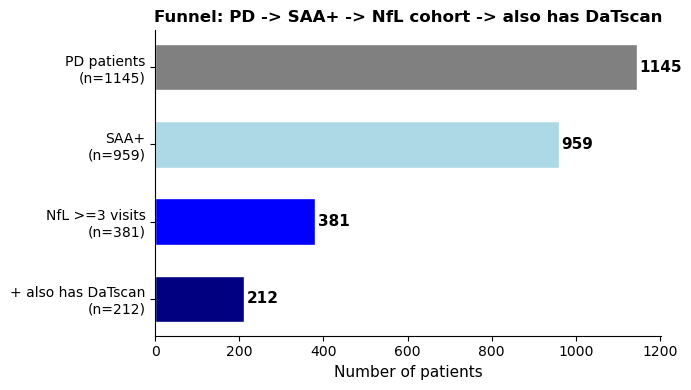

In [22]:
labels = [
    f'PD patients\n(n={len(pd_patnos_all)})',
    f'SAA+\n(n={len(saa_pos_patnos)})',
    f'NfL >=3 visits\n(n={len(nfl_cohort_patnos)})',
    f'+ also has DaTscan\n(n={len(datscan_patnos)})'
]
values = [len(pd_patnos_all), len(saa_pos_patnos), len(nfl_cohort_patnos), len(datscan_patnos)]
colors = ['gray', 'lightblue', 'blue', 'navy']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels, values, color=colors, edgecolor='white', height=0.6)
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Number of patients', fontsize=11)
ax.set_title('Funnel: PD -> SAA+ -> NfL cohort -> also has DaTscan', fontsize=12, fontweight='bold')
ax.invert_yaxis()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{OUT}/Funnel_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5 — Align NfL and DaTscan visits (nearest date, <=180 days)
NfL and DaTscan are not measured on the same visit — pair each NfL visit with the nearest
DaTscan visit for the same patient, within 180 days.

In [23]:
MAX_DAYS = 180
nfl_final = nfl_df[nfl_df['PATNO'].isin(datscan_patnos)].copy()

rows = []
for _, r in nfl_final.iterrows():
    pat_dat = dfd[dfd['PATNO'] == r['PATNO']].copy()
    if pat_dat.empty: continue
    pat_dat['days_diff'] = (pat_dat['EXAMDT'] - r['EXAMDT']).dt.days.abs()
    nearest = pat_dat.loc[pat_dat['days_diff'].idxmin()]
    if nearest['days_diff'] <= MAX_DAYS:
        rows.append({
            'PATNO': r['PATNO'], 'EVENT_ID': r['EVENT_ID'], 'EXAMDT': r['EXAMDT'],
            'NfL': r['NfL'], 'NfL_log2': r['NfL_log2'], 'NP3TOT': r['NP3TOT'],
            'AGE_AT_VISIT': r['AGE_AT_VISIT'], 'SEX_bin': r['SEX_bin'],
            'SBR_less': nearest['SBR_less'], 'MOTOR_less': nearest['MOTOR_less'],
            'days_gap': nearest['days_diff'],
        })

merged = pd.DataFrame(rows)
print(f'Aligned visits (<= {MAX_DAYS} days): {len(merged)} across {merged["PATNO"].nunique()} patients')
print(f'Mean days gap: {merged["days_gap"].mean():.1f}')

Aligned visits (<= 180 days): 506 across 210 patients
Mean days gap: 19.3


---
## Step 6 — LMM: NfL vs MDS-UPDRS III (funnel cohort)
`NP3TOT ~ NfL_log2 + AGE_AT_VISIT + SEX_bin`, random intercept + slope per patient.

In [24]:
m1 = merged.dropna(subset=['AGE_AT_VISIT','SEX_bin','NfL_log2','NP3TOT'])
model1 = smf.mixedlm('NP3TOT ~ NfL_log2 + AGE_AT_VISIT + SEX_bin',
                     data=m1, groups=m1['PATNO'].astype(str), re_formula='~NfL_log2')
res1 = model1.fit(method='lbfgs')
ci1 = res1.conf_int()
print(f'>=3 visits (used): UPDRS pts/doubling = {res1.params["NfL_log2"]:.2f}, '
      f'95% CI=[{ci1.loc["NfL_log2",0]:.2f}, {ci1.loc["NfL_log2",1]:.2f}], '
      f'p={res1.pvalues["NfL_log2"]:.4f}')

# Reference line: what if we had used >=4 visits instead?
print('>=4 visits (reference): UPDRS pts/doubling = 2.36, 95% CI=[0.33, 4.39], p=0.0225')
print(res1.summary())

>=3 visits (used): UPDRS pts/doubling = 2.27, 95% CI=[0.52, 4.01], p=0.0109
>=4 visits (reference): UPDRS pts/doubling = 2.36, 95% CI=[0.33, 4.39], p=0.0225
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   NP3TOT    
No. Observations:   504       Method:               REML      
No. Groups:         210       Scale:                35.1601   
Min. group size:    1         Log-Likelihood:       -1773.0720
Max. group size:    4         Converged:            Yes       
Mean group size:    2.4                                       
--------------------------------------------------------------
                     Coef.  Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept             8.334    4.092 2.037 0.042  0.314 16.353
NfL_log2              2.266    0.890 2.546 0.011  0.521  4.010
AGE_AT_VISIT          0.093    0.079 1.177 0.239 -0.062  0.247
SEX_bin               1.525    1.245 

---
## Step 7 — LMM: DaTscan SBR vs lateralized UPDRS (funnel cohort)
`MOTOR_less ~ SBR_less + AGE_AT_VISIT + SEX_bin`, random intercept + slope per patient.

In [25]:
m2 = merged.dropna(subset=['AGE_AT_VISIT','SEX_bin','SBR_less','MOTOR_less'])
model2 = smf.mixedlm('MOTOR_less ~ SBR_less + AGE_AT_VISIT + SEX_bin',
                     data=m2, groups=m2['PATNO'].astype(str), re_formula='~SBR_less')
res2 = model2.fit(method='lbfgs')
ci2 = res2.conf_int()
print(f'Beta (SBR_less) = {res2.params["SBR_less"]:.3f}, '
      f'95% CI=[{ci2.loc["SBR_less",0]:.3f}, {ci2.loc["SBR_less",1]:.3f}], '
      f'p={res2.pvalues["SBR_less"]:.4f}')
print(res2.summary())

Beta (SBR_less) = -5.075, 95% CI=[-6.471, -3.678], p=0.0000
             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   MOTOR_less
No. Observations:     504       Method:               REML      
No. Groups:           210       Scale:                4.8103    
Min. group size:      1         Log-Likelihood:       -1243.0130
Max. group size:      4         Converged:            Yes       
Mean group size:      2.4                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              2.561    1.423  1.800 0.072 -0.228  5.349
SBR_less              -5.075    0.713 -7.121 0.000 -6.471 -3.678
AGE_AT_VISIT           0.080    0.021  3.893 0.000  0.040  0.121
SEX_bin               -0.427    0.378 -1.130 0.258 -1.169  0.314
Group Var             16.360    2.608       

---
## Step 8 — LMM: NfL vs DaTscan SBR (funnel cohort)
`SBR_less ~ NfL_log2 + AGE_AT_VISIT + SEX_bin`, random intercept + slope per patient.

In [26]:
m3 = merged.dropna(subset=['AGE_AT_VISIT','SEX_bin','NfL_log2','SBR_less'])
model3 = smf.mixedlm('SBR_less ~ NfL_log2 + AGE_AT_VISIT + SEX_bin',
                     data=m3, groups=m3['PATNO'].astype(str), re_formula='~NfL_log2')
res3 = model3.fit(method='lbfgs')
ci3 = res3.conf_int()
print(f'Beta (NfL_log2) = {res3.params["NfL_log2"]:.4f}, '
      f'95% CI=[{ci3.loc["NfL_log2",0]:.4f}, {ci3.loc["NfL_log2",1]:.4f}], '
      f'p={res3.pvalues["NfL_log2"]:.4f}')
print(res3.summary())

Beta (NfL_log2) = -0.0325, 95% CI=[-0.0714, 0.0063], p=0.1010
             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    SBR_less
No. Observations:    504        Method:                REML    
No. Groups:          210        Scale:                 0.0117  
Min. group size:     1          Log-Likelihood:        136.2728
Max. group size:     4          Converged:             Yes     
Mean group size:     2.4                                       
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             1.300    0.122 10.627 0.000  1.060  1.540
NfL_log2             -0.033    0.020 -1.640 0.101 -0.071  0.006
AGE_AT_VISIT         -0.007    0.002 -3.024 0.002 -0.011 -0.002
SEX_bin              -0.033    0.035 -0.946 0.344 -0.103  0.036
Group Var             0.033    0.311                   

---
## Step 9 — Scatter plots for the 3 LMMs

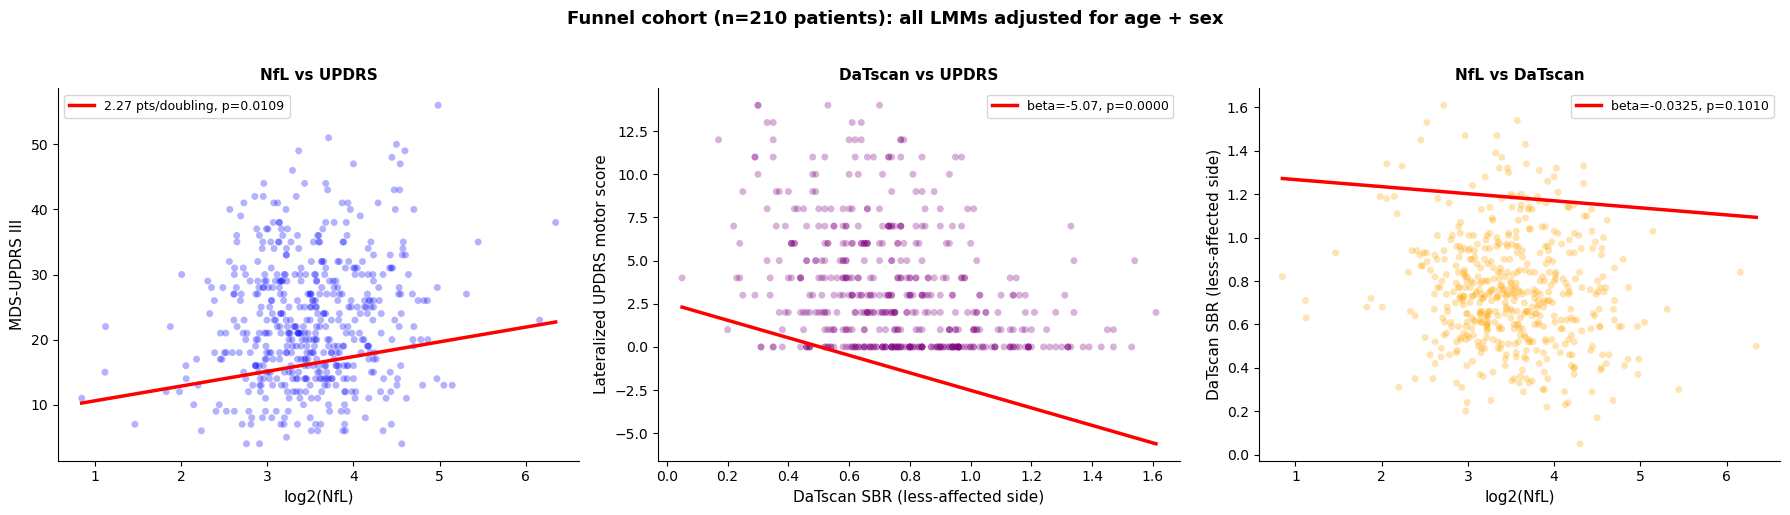

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(m1['NfL_log2'], m1['NP3TOT'], alpha=0.3, s=25, color='blue', edgecolor='none')
xs = np.linspace(m1['NfL_log2'].min(), m1['NfL_log2'].max(), 100)
ys = res1.params['Intercept'] + res1.params['NfL_log2']*xs
ax.plot(xs, ys, color='red', lw=2.5,
        label=f'{res1.params["NfL_log2"]:.2f} pts/doubling, p={res1.pvalues["NfL_log2"]:.4f}')
ax.set_xlabel('log2(NfL)', fontsize=11)
ax.set_ylabel('MDS-UPDRS III', fontsize=11)
ax.set_title('NfL vs UPDRS', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)

ax = axes[1]
ax.scatter(m2['SBR_less'], m2['MOTOR_less'], alpha=0.3, s=25, color='purple', edgecolor='none')
xs = np.linspace(m2['SBR_less'].min(), m2['SBR_less'].max(), 100)
ys = res2.params['Intercept'] + res2.params['SBR_less']*xs
ax.plot(xs, ys, color='red', lw=2.5,
        label=f'beta={res2.params["SBR_less"]:.2f}, p={res2.pvalues["SBR_less"]:.4f}')
ax.set_xlabel('DaTscan SBR (less-affected side)', fontsize=11)
ax.set_ylabel('Lateralized UPDRS motor score', fontsize=11)
ax.set_title('DaTscan vs UPDRS', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)

ax = axes[2]
ax.scatter(m3['NfL_log2'], m3['SBR_less'], alpha=0.3, s=25, color='orange', edgecolor='none')
xs = np.linspace(m3['NfL_log2'].min(), m3['NfL_log2'].max(), 100)
ys = res3.params['Intercept'] + res3.params['NfL_log2']*xs
ax.plot(xs, ys, color='red', lw=2.5,
        label=f'beta={res3.params["NfL_log2"]:.4f}, p={res3.pvalues["NfL_log2"]:.4f}')
ax.set_xlabel('log2(NfL)', fontsize=11)
ax.set_ylabel('DaTscan SBR (less-affected side)', fontsize=11)
ax.set_title('NfL vs DaTscan', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)

plt.suptitle(f'Funnel cohort (n={merged["PATNO"].nunique()} patients): all LMMs adjusted for age + sex',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}/Funnel_Fig_3panel_LMM.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 10 — NfL trajectory: funnel cohort (PD) vs Healthy Controls

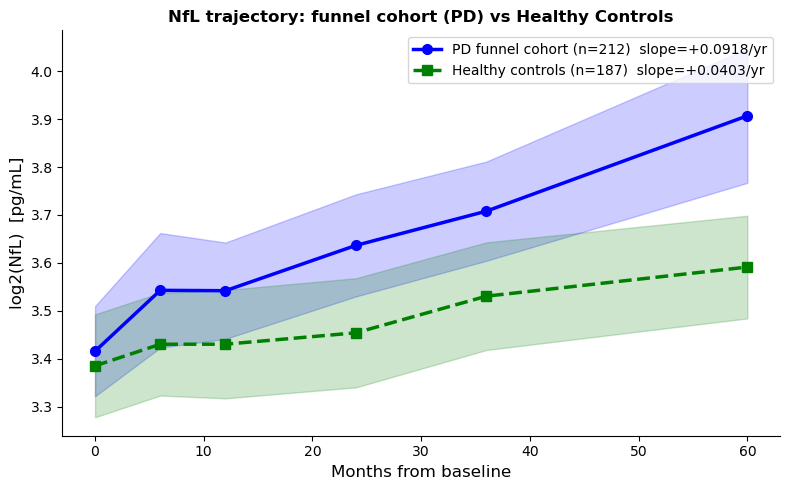

In [28]:
from scipy.stats import sem as scipy_sem, linregress

event_months = {'BL':0,'V02':6,'V04':12,'V06':24,'V08':36,'V10':48,'V12':60}

nfl_pd_traj = nfl_final[['PATNO','EVENT_ID','NfL_log2']].copy()
nfl_pd_traj['months'] = nfl_pd_traj['EVENT_ID'].map(event_months)
nfl_pd_traj = nfl_pd_traj.dropna(subset=['months'])

ctrl_patnos = bio[bio['COHORT'] == 'Control']['PATNO'].unique()
nfl_hc = bio[(bio['TESTNAME'] == 'NfL') & (bio['PATNO'].isin(ctrl_patnos))].copy()
nfl_hc = nfl_hc[['PATNO','CLINICAL_EVENT','TESTVALUE']].rename(
    columns={'TESTVALUE':'NfL','CLINICAL_EVENT':'EVENT_ID'})
nfl_hc['NfL'] = pd.to_numeric(nfl_hc['NfL'], errors='coerce')
nfl_hc = nfl_hc[(nfl_hc['NfL'] > 0) & (nfl_hc['NfL'] <= 150)].dropna(subset=['NfL'])
nfl_hc['NfL_log2'] = np.log2(nfl_hc['NfL'])
nfl_hc['months'] = nfl_hc['EVENT_ID'].map(event_months)
nfl_hc = nfl_hc.dropna(subset=['months'])

def traj(df):
    rows = []
    for m, g in df.groupby('months'):
        v = g['NfL_log2'].dropna().values
        if len(v) < 3: continue
        mu = v.mean(); ci = 1.96 * scipy_sem(v)
        rows.append({'months': m, 'mean': mu, 'lo': mu-ci, 'hi': mu+ci})
    return pd.DataFrame(rows).sort_values('months')

t_pd = traj(nfl_pd_traj)
t_hc = traj(nfl_hc)
sl_pd = linregress(nfl_pd_traj['months'], nfl_pd_traj['NfL_log2'])
sl_hc = linregress(nfl_hc['months'], nfl_hc['NfL_log2'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(t_pd['months'], t_pd['lo'], t_pd['hi'], alpha=0.2, color='blue')
ax.plot(t_pd['months'], t_pd['mean'], 'o-', color='blue', lw=2.5, ms=7,
        label=f'PD funnel cohort (n={nfl_pd_traj["PATNO"].nunique()})  slope={sl_pd.slope*12:+.4f}/yr')
ax.fill_between(t_hc['months'], t_hc['lo'], t_hc['hi'], alpha=0.2, color='green')
ax.plot(t_hc['months'], t_hc['mean'], 's--', color='green', lw=2.5, ms=7,
        label=f'Healthy controls (n={nfl_hc["PATNO"].nunique()})  slope={sl_hc.slope*12:+.4f}/yr')
ax.set_xlabel('Months from baseline', fontsize=12)
ax.set_ylabel('log2(NfL)  [pg/mL]', fontsize=12)
ax.set_title('NfL trajectory: funnel cohort (PD) vs Healthy Controls', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{OUT}/Funnel_Fig_NfL_trajectory_PD_vs_HC.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 11 — Laterality check: right-tracked vs left-tracked patients
Each patient's *less-affected* side was determined at baseline. Check the split,
and whether the SBR-motor correlation differs between the two groups.

side
Right tracked    110
Left tracked     100
Name: count, dtype: int64


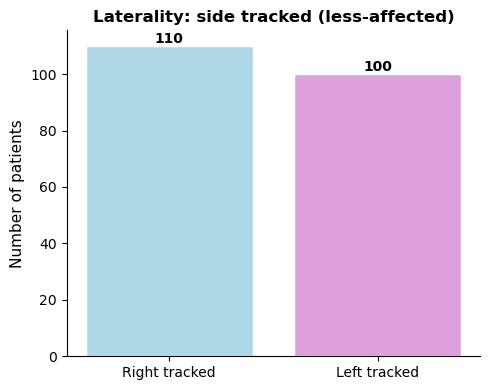

In [29]:
side_per_patient = baseline[baseline['PATNO'].isin(merged['PATNO'])][['PATNO','track_putamen']].copy()
side_per_patient['side'] = side_per_patient['track_putamen'].map(
    {'PUTAMEN_L_REF_CWM': 'Left tracked', 'PUTAMEN_R_REF_CWM': 'Right tracked'})

counts = side_per_patient['side'].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts.index, counts.values, color=['lightblue', 'plum'], edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
ax.set_ylabel('Number of patients', fontsize=11)
ax.set_title('Laterality: side tracked (less-affected)', fontsize=12, fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{OUT}/Funnel_Fig_laterality_counts.png', dpi=150, bbox_inches='tight')
plt.show()

Left tracked: n=100 patients, r=-0.320, p=0.0000
Right tracked: n=110 patients, r=-0.386, p=0.0000


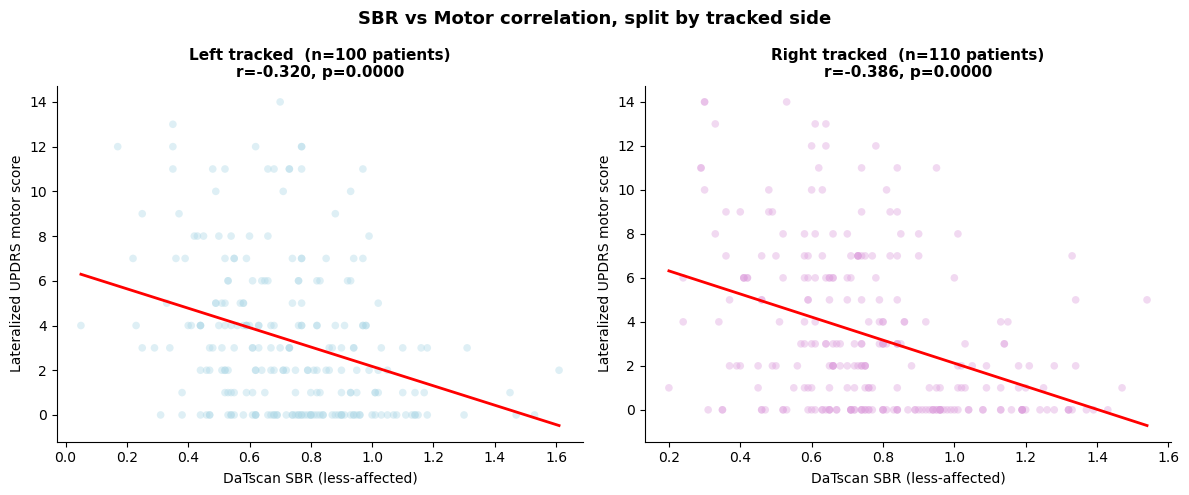

In [30]:
merged_side = merged.merge(side_per_patient[['PATNO','side']], on='PATNO', how='left')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, side_label, color in zip(axes, ['Left tracked', 'Right tracked'], ['lightblue', 'plum']):
    sub = merged_side[merged_side['side'] == side_label].dropna(subset=['SBR_less','MOTOR_less'])
    ax.scatter(sub['SBR_less'], sub['MOTOR_less'], alpha=0.4, s=30, color=color, edgecolor='none')
    if len(sub) >= 5:
        r, p = stats.pearsonr(sub['SBR_less'], sub['MOTOR_less'])
        m, b = np.polyfit(sub['SBR_less'], sub['MOTOR_less'], 1)
        xs = np.linspace(sub['SBR_less'].min(), sub['SBR_less'].max(), 100)
        ax.plot(xs, m*xs + b, color='red', lw=2)
        ax.set_title(f'{side_label}  (n={sub["PATNO"].nunique()} patients)\n'
                     f'r={r:.3f}, p={p:.4f}', fontsize=11, fontweight='bold')
        print(f'{side_label}: n={sub["PATNO"].nunique()} patients, r={r:.3f}, p={p:.4f}')
    ax.set_xlabel('DaTscan SBR (less-affected)', fontsize=10)
    ax.set_ylabel('Lateralized UPDRS motor score', fontsize=10)
    sns.despine(ax=ax)

plt.suptitle('SBR vs Motor correlation, split by tracked side', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/Funnel_Fig_laterality_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Save funnel dataset

In [31]:
csv_out = os.path.join(OUT, 'Funnel_NfL_DaTscan_dataset.csv')
merged.to_csv(csv_out, index=False)
print(f'Saved: {csv_out}')
print(f'Patients: {merged["PATNO"].nunique()}, Visits: {len(merged)}')

Saved: ..\..\04_Data\Results\results_funnel\Funnel_NfL_DaTscan_dataset.csv
Patients: 210, Visits: 506


---
## Step 12 — Within-between (Mundlak) decomposition
Applied to the two clinically central relationships: NfL -> UPDRS and DaTscan -> UPDRS.
NfL -> DaTscan was excluded here, since it was already a marginal, non-significant association
(p=0.061) and would benefit least from this decomposition.

**Caveat:** after aligning NfL and DaTscan visits, many patients have only 1-4 visits
(mean ~2.3, min 1). A patient with a single visit contributes nothing to the within-patient
component (their deviation from their own mean is 0 by construction), so the within estimate
here is based on less effective information than in the main NfL-only cohort (mean 4.3 visits).

In [32]:
def add_mundlak(d, var):
    g = d.groupby('PATNO')[var]
    d = d.copy()
    d[var + '_mean'] = g.transform('mean')      # BETWEEN
    d[var + '_cwc']  = d[var] - d[var + '_mean'] # WITHIN
    return d

def fit_mundlak(data, outcome, predictor):
    d = data.dropna(subset=[outcome, predictor, 'AGE_AT_VISIT', 'SEX_bin']).copy()
    d = add_mundlak(d, predictor)
    n_pat, n_vis = d['PATNO'].nunique(), len(d)
    rows = []
    def grab(res, term, label, model):
        ci = res.conf_int()
        rows.append([outcome, predictor, model, label, res.params[term],
                     ci.loc[term,0], ci.loc[term,1], res.pvalues[term], n_pat, n_vis])
    r1 = smf.mixedlm(f'{outcome} ~ {predictor} + AGE_AT_VISIT + SEX_bin',
                     d, groups=d['PATNO'].astype(str)).fit(method='lbfgs')
    grab(r1, predictor, 'conflated', 'Conflated')
    cwc, mean_ = f'{predictor}_cwc', f'{predictor}_mean'
    r2 = smf.mixedlm(f'{outcome} ~ {cwc} + {mean_} + AGE_AT_VISIT + SEX_bin',
                     d, groups=d['PATNO'].astype(str)).fit(method='lbfgs')
    grab(r2, cwc, 'within', 'Mundlak')
    grab(r2, mean_, 'between', 'Mundlak')
    r3 = smf.mixedlm(f'{outcome} ~ {predictor} + {mean_} + AGE_AT_VISIT + SEX_bin',
                     d, groups=d['PATNO'].astype(str)).fit(method='lbfgs')
    grab(r3, mean_, 'gamma (between - within)', 'Hausman')
    return rows

results  = fit_mundlak(merged, 'NP3TOT', 'NfL_log2')
results += fit_mundlak(merged, 'MOTOR_less', 'SBR_less')

res_funnel = pd.DataFrame(results, columns=['Outcome','Predictor','Model','Term',
                                             'beta','CI_low','CI_high','p','n_pat','n_vis'])
res_funnel[['beta','CI_low','CI_high']] = res_funnel[['beta','CI_low','CI_high']].round(4)
res_funnel['p'] = res_funnel['p'].round(4)
res_funnel['sig'] = np.where(res_funnel['p'] < 0.05, '*', '')
pd.set_option('display.width', 160); pd.set_option('display.max_columns', None)
print(res_funnel.to_string(index=False))
print()
print('Note: random slope (re_formula) was not used here -- random intercept only --')
print('because the small mean visit count per patient (~2.3) makes a random-slope model')
print('unstable / prone to convergence issues in this funnel cohort.')

   Outcome Predictor     Model                     Term    beta  CI_low  CI_high      p  n_pat  n_vis sig
    NP3TOT  NfL_log2 Conflated                conflated  2.2769  0.6758   3.8779 0.0053    210    504   *
    NP3TOT  NfL_log2   Mundlak                   within  3.5740  1.4888   5.6593 0.0008    210    504   *
    NP3TOT  NfL_log2   Mundlak                  between  0.6267 -1.7302   2.9836 0.6023    210    504    
    NP3TOT  NfL_log2   Hausman gamma (between - within) -2.9473 -6.0126   0.1179 0.0595    210    504    
MOTOR_less  SBR_less Conflated                conflated -5.2772 -6.5758  -3.9787 0.0000    210    504   *
MOTOR_less  SBR_less   Mundlak                   within -7.3500 -9.5906  -5.1093 0.0000    210    504   *
MOTOR_less  SBR_less   Mundlak                  between -4.2748 -5.8381  -2.7115 0.0000    210    504   *
MOTOR_less  SBR_less   Hausman gamma (between - within)  3.0752  0.3508   5.7996 0.0269    210    504   *

Note: random slope (re_formula) was not used 